In [ ]:
# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]
def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

# This block was previously inside the function and mis-indented
if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

# These imports and subsequent data loading/processing were also mis-indented
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
# keep only numeric sensor columns (drop any non-sensor / label-like columns)
sensors = [c for c in df.columns if df[c].dtype != 'object' and c.lower() not in ('condition','label','machine_id','id')]
X = df[sensors].copy()
print('readings:', X.shape, '| sensors:', len(sensors))
info.head(4)

Generated dataset files.
readings: (2000, 24) | sensors: 24


,sensor,unit,group
0,temp_bearing,C,thermal
1,temp_motor,C,thermal
2,temp_gearbox,C,thermal
3,oil_temp,C,thermal


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THREE WAYS TO MEASURE DISTANCE BETWEEN TWO READINGS
# -----------------------------------------------------------
from scipy.spatial.distance import euclidean, cityblock, cosine
a = X.iloc[0].values; b = X.iloc[1].values
print('Euclidean (straight line):', round(euclidean(a, b), 2))
print('Manhattan (city block)   :', round(cityblock(a, b), 2))
print('Cosine (1 - cos angle)   :', round(cosine(a, b), 4))
print('\nEach answers "how similar?" differently — the choice shapes every unsupervised result.')


NameError: name 'X' is not defined

In [ ]:
print('Sensor Data Summary Statistics:')
display(X.describe())

Sensor Data Summary Statistics:


,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,rpm,...,current_a,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,66.261035,70.205995,62.222115,58.149490,27.977065,2.214185,2.011560,1.81195,78.028955,1805.331960,...,22.063925,22.083835,22.04873,64.978270,80.232190,60.184405,30.109740,79.954475,414.999070,44.992160
std,7.276843,8.245558,6.877791,5.133618,1.322453,0.756559,0.758426,0.58680,5.301880,400.702613,...,5.410255,5.465301,5.44654,16.213763,10.085492,8.270902,4.768856,4.488197,0.302834,0.199386
min,39.580000,41.760000,35.910000,39.470000,23.020000,0.000000,0.000000,0.00000,59.380000,501.800000,...,3.980000,5.070000,4.85000,7.660000,45.720000,33.480000,15.460000,61.620000,413.890000,44.270000
25%,61.480000,64.992500,57.495000,54.797500,27.110000,1.700000,1.490000,1.41000,74.457500,1547.755000,...,18.515000,18.457500,18.44750,54.070000,73.315000,54.745000,26.960000,77.040000,414.800000,44.850000
50%,66.200000,70.075000,62.445000,58.135000,27.975000,2.200000,2.000000,1.81000,77.830000,1807.060000,...,22.175000,22.175000,22.04500,65.165000,80.395000,60.130000,29.990000,79.925000,415.000000,44.990000
75%,71.140000,75.632500,66.765000,61.770000,28.850000,2.730000,2.530000,2.22000,81.622500,2078.100000,...,25.672500,25.742500,25.84000,75.630000,87.192500,65.602500,33.405000,83.062500,415.210000,45.140000
max,90.380000,96.970000,87.030000,75.180000,33.020000,4.480000,4.490000,3.80000,95.740000,3093.370000,...,39.000000,39.220000,39.31000,116.610000,111.560000,87.600000,46.290000,94.560000,416.120000,45.680000


In [ ]:
from sklearn.metrics import pairwise_distances
import numpy as np

# Compute Euclidean distance between all readings
distances = pairwise_distances(X, metric='euclidean')   # Replace X with your dataset if needed

# Ignore the distance from row 0 to itself
distances[0, 0] = np.inf

# Find the index of the nearest neighbour to row 0
nearest_index = np.argmin(distances[0])

# Print the result
print("Nearest neighbour index:", nearest_index)
print("Distance:", distances[0, nearest_index])

Nearest neighbour index: 396
Distance: 22.84088439586649


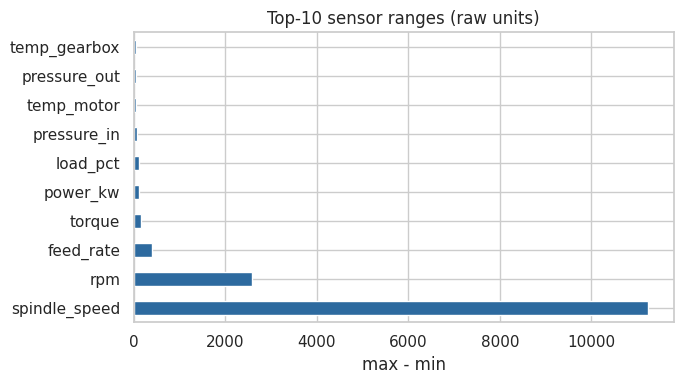

The widest-range sensor alone would dominate any distance calculation.


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. FEATURE RANGES ARE WILDLY DIFFERENT
# -----------------------------------------------------------
ranges = (X.max() - X.min()).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
ranges.head(10).plot(kind='barh', color='#2D6A9F', ax=ax)
ax.set_title('Top-10 sensor ranges (raw units)'); ax.set_xlabel('max - min')
plt.tight_layout(); plt.show()
print('The widest-range sensor alone would dominate any distance calculation.')



In [ ]:

# -----------------------------------------------------------
# 🔹 2B. SCALING CHANGES WHICH READING IS 'NEAREST'
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)
raw_nn = pairwise_distances(X.values[[0]], X.values)[0]
scaled_nn = pairwise_distances(Xs[[0]], Xs)[0]
raw_nn[0] = scaled_nn[0] = np.inf   # ignore self
print('nearest to row 0 on RAW data   :', int(np.argmin(raw_nn)))
print('nearest to row 0 on SCALED data:', int(np.argmin(scaled_nn)))
print('Different answers — unscaled distance is decided by the biggest-range sensor.')

nearest to row 0 on RAW data   : 396
nearest to row 0 on SCALED data: 901
Different answers — unscaled distance is decided by the biggest-range sensor.


In [ ]:
import pandas as pd

# If your data is a DataFrame
std_values = X.std().sort_values(ascending=False)

print("Standard deviations (highest to lowest):")
print(std_values)


Standard deviations (highest to lowest):
spindle_speed    1721.473671
rpm               400.702613
feed_rate          59.965949
torque             27.158125
power_kw           20.950164
load_pct           16.213763
pressure_in        10.085492
pressure_out        8.270902
temp_motor          8.245558
temp_bearing        7.276843
temp_gearbox        6.877791
current_b           5.465301
current_c           5.446540
current_a           5.410255
acoustic_db         5.301880
oil_temp            5.133618
coolant_flow        4.768856
oil_level           4.488197
temp_ambient        1.322453
vibration_y         0.758426
vibration_x         0.756559
vibration_z         0.586800
voltage             0.302834
humidity            0.199386
dtype: float64


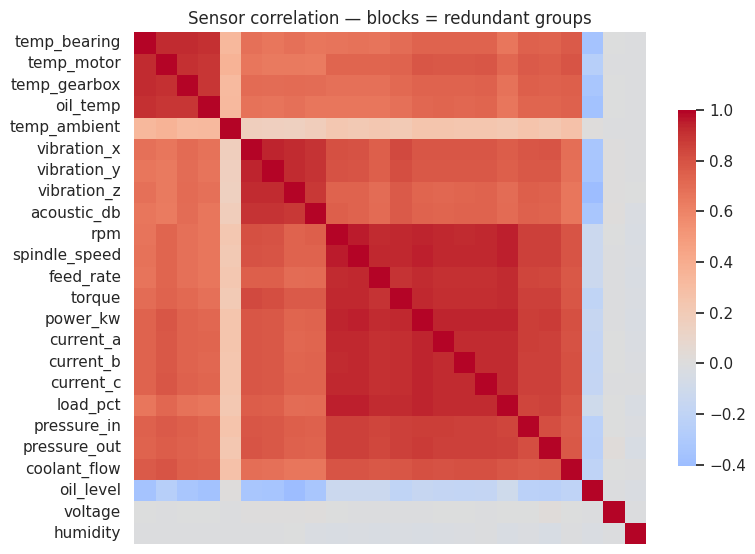

Strong blocks mean the 24 sensors carry far fewer than 24 independent signals.


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. MANY SENSORS ARE REDUNDANT (CORRELATED)
# -----------------------------------------------------------
corr = X.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            xticklabels=False, yticklabels=True, cbar_kws={'shrink': 0.6}, ax=ax)
ax.set_title('Sensor correlation — blocks = redundant groups'); plt.tight_layout(); plt.show()
print('Strong blocks mean the 24 sensors carry far fewer than 24 independent signals.')


In [ ]:
import numpy as np
import pandas as pd

# 1. Find near-constant sensors (raw standard deviation < 1% of median std)

# Compute raw standard deviations
std_values = X.std()

# Threshold = 1% of the median standard deviation
threshold = 0.01 * std_values.median()

# Find near-constant sensors
near_constant = std_values[std_values < threshold]

print("Threshold:", threshold)
print("\nNear-constant sensors:")
print(near_constant)

Threshold: 0.054559203716852064

Near-constant sensors:
Series([], dtype: float64)


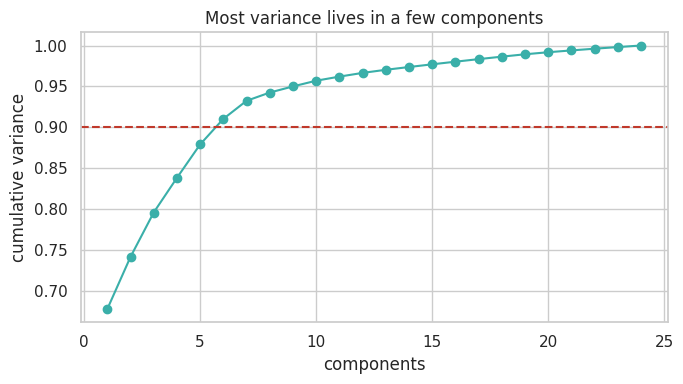

6 components explain >=90% of the variance (out of 24 sensors).


In [ ]:

# -----------------------------------------------------------
# 🔹 4A. PCA — HOW MANY COMPONENTS CAPTURE THE VARIANCE?
# -----------------------------------------------------------
from sklearn.decomposition import PCA
pca = PCA().fit(Xs)
cum = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum, 'o-', color='#3AAFA9')
ax.axhline(0.9, ls='--', color='#C0392B'); ax.set_xlabel('components'); ax.set_ylabel('cumulative variance')
ax.set_title('Most variance lives in a few components'); plt.tight_layout(); plt.show()
n90 = int(np.argmax(cum >= 0.9) + 1)
print(f'{n90} components explain >=90% of the variance (out of {len(sensors)} sensors).')

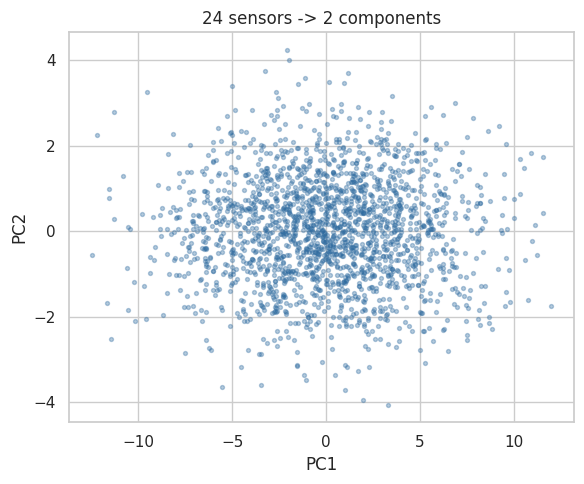

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. PROJECT TO 2-D TO SEE THE DATA
# -----------------------------------------------------------
P2 = PCA(n_components=2).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=8, alpha=0.35, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('24 sensors -> 2 components')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.decomposition import PCA

# 1. PCA to n90 components
# Assume X_scaled is your standardized dataset and n90 is already computed

pca = PCA(n_components=n90, random_state=42)
X_pca = pca.fit_transform(Xs)

print("Original dimensions:", Xs.shape[1])
print("Reduced dimensions:", X_pca.shape[1])
print("Dimensions dropped:", Xs.shape[1] - X_pca.shape[1])
print("Explained variance retained:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

Original dimensions: 24
Reduced dimensions: 6
Dimensions dropped: 18
Explained variance retained: 91.02 %


30 readings lie >3 sigma from the centre (candidate anomalies).


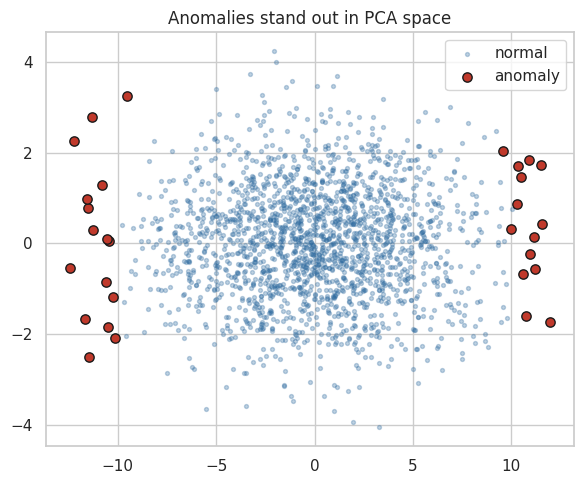

In [ ]:

# -----------------------------------------------------------
# 🔹 5A. DISTANCE-FROM-CENTRE FLAGS OUTLIERS
# -----------------------------------------------------------
centre = Xs.mean(axis=0)
dist = np.linalg.norm(Xs - centre, axis=1)
thresh = np.mean(dist) + 3 * np.std(dist)
outliers = np.where(dist > thresh)[0]
print(f'{len(outliers)} readings lie >3 sigma from the centre (candidate anomalies).')
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=8, alpha=0.3, color='#2D6A9F', label='normal')
ax.scatter(P2[outliers, 0], P2[outliers, 1], s=45, color='#C0392B', label='anomaly', edgecolor='k')
ax.legend(); ax.set_title('Anomalies stand out in PCA space'); plt.tight_layout(); plt.show()

In [ ]:
print("Anomalous sensor readings:")
print(df.iloc[outliers])

# (Optional) Display only selected sensors if they exist
# print(df.loc[outliers, ['temperature', 'vibration']])

Anomalous sensor readings:
     machine_id  temp_bearing  temp_motor  temp_gearbox  oil_temp  \
117      MX0118         82.51       87.79         76.20     72.02   
324      MX0325         83.06       90.23         79.32     71.14   
346      MX0347         51.73       51.04         43.65     43.39   
353      MX0354         53.84       58.22         53.49     49.02   
431      MX0432         83.94       88.98         78.85     72.29   
461      MX0462         74.11       80.07         69.83     64.87   
655      MX0656         48.02       54.47         44.12     47.33   
733      MX0734         90.38       96.97         87.03     75.18   
784      MX0785         79.92       82.36         73.82     67.87   
819      MX0820         47.08       50.36         43.75     43.66   
840      MX0841         87.79       90.09         83.22     70.60   
896      MX0897         81.93       87.28         79.84     73.79   
902      MX0903         75.27       79.28         70.98     66.44   
987    